#Comparison of Machine Learning Models Under Missing Data

## Introduction

Previous experiments evaluated the effect of missing data on three machine learning algorithms separately:

- Logistic Regression
- Decision Tree
- Random Forest

This experiment combines the results to compare the robustness of different models under increasing levels of missing data.

The objective is to determine which classifier maintains the highest predictive performance when the dataset becomes incomplete.

## Import Libraries

The following libraries are required for loading the experimental results and creating comparison visualizations.

In [8]:
import pandas as pd

import matplotlib.pyplot as plt

## Load Experimental Results

The evaluation results obtained from previous experiments are loaded for comparison.

Each file contains the performance of one machine learning algorithm under different levels of missing data.

In [13]:
logistic = pd.read_csv("logistic_regression_missing_data.csv")

decision_tree = pd.read_csv("decision_tree_missing_data.csv")

random_forest = pd.read_csv("random_forest_missing_data.csv")

## Label Each Model

A new column is added to each DataFrame to identify which machine learning algorithm produced the corresponding results.

This will allow all experiments to be combined into a single comparison table.

In [14]:
logistic["Model"] = "Logistic Regression"

decision_tree["Model"] = "Decision Tree"

random_forest["Model"] = "Random Forest"

## Combine All Results

The three experimental result tables are merged into a single DataFrame.

This allows all machine learning models to be compared within one table.

In [19]:
comparison = pd.concat([logistic, decision_tree, random_forest ],ignore_index=True)

comparison

,Missing Data,Accuracy,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive,Model
0,0%,0.810,0.786,0.743,0.764,90,15,19,55,Logistic Regression
1,10%,0.777,0.730,0.730,0.730,85,20,20,54,Logistic Regression
2,20%,0.765,0.705,0.743,0.724,82,23,19,55,Logistic Regression
3,30%,0.765,0.705,0.743,0.724,82,23,19,55,Logistic Regression
4,0%,0.782,0.727,0.757,0.742,84,21,18,56,Decision Tree
5,10%,0.810,0.763,0.784,0.773,87,18,16,58,Decision Tree
6,20%,0.793,0.761,0.730,0.745,88,17,20,54,Decision Tree
7,30%,0.788,0.781,0.676,0.725,91,14,24,50,Decision Tree
8,0%,0.821,0.800,0.757,0.778,91,14,18,56,Random Forest
9,10%,0.799,0.757,0.757,0.757,87,18,18,56,Random Forest


## Compare Model Accuracy

A line chart is created to compare how the Accuracy of each machine learning model changes as the amount of missing data increases.

This visualization makes it easier to identify which algorithm is the most robust.

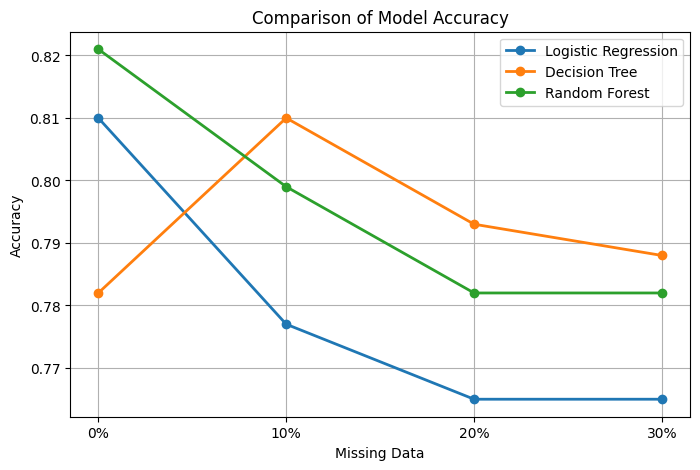

In [16]:
plt.figure(figsize=(8,5))

for model in comparison["Model"].unique():

    data = comparison[comparison["Model"] == model]

    plt.plot(data["Missing Data"], data["Accuracy"],marker="o", linewidth=2,label=model)

plt.xlabel("Missing Data")

plt.ylabel("Accuracy")

plt.title("Comparison of Model Accuracy")

plt.grid(True)

plt.legend()

plt.savefig("model_accuracy_comparison.png")

plt.show()

## Compare F1-score

The F1-score is compared across all machine learning models under different levels of missing data.

Unlike Accuracy, the F1-score considers both Precision and Recall, providing a more balanced evaluation of model performance.

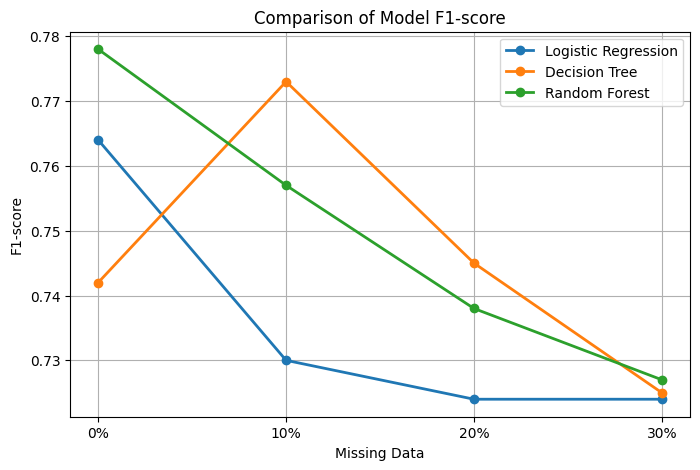

In [17]:
plt.figure(figsize=(8,5))

for model in comparison["Model"].unique():

    data = comparison[comparison["Model"] == model ]

    plt.plot( data["Missing Data"],data["F1-score"], marker="o",linewidth=2, label=model)

plt.xlabel("Missing Data")

plt.ylabel("F1-score")

plt.title("Comparison of Model F1-score")

plt.grid(True)

plt.legend()

plt.savefig("model_f1_comparison.png")

plt.show()

## Analysis of Results

The comparison shows that the effect of missing data differs between the three machine learning models.

Random Forest achieved the highest performance on the complete dataset, with an Accuracy of 0.821 and an F1-score of 0.778. This was the best overall baseline performance among the three models.

At 10% missing data, Decision Tree achieved the highest Accuracy of 0.810 and the highest F1-score of 0.773. Logistic Regression showed the largest decrease in performance at this level, with Accuracy falling to 0.777 and F1-score decreasing to 0.730. Random Forest remained relatively stable, with an Accuracy of 0.799 and an F1-score of 0.757.

At 20% missing data, Decision Tree continued to achieve the highest Accuracy of 0.793 and F1-score of 0.745. Random Forest achieved an Accuracy of 0.782 and an F1-score of 0.738, while Logistic Regression had the lowest Accuracy of 0.765 and an F1-score of 0.724.

At 30% missing data, Decision Tree again achieved the highest Accuracy at 0.788. However, its F1-score decreased to 0.725 because Recall dropped to 0.676. Random Forest achieved an Accuracy of 0.782 and an F1-score of 0.727, while Logistic Regression remained at an Accuracy of 0.765 and an F1-score of 0.724.

Overall, Logistic Regression showed the clearest decrease in Accuracy as missing data increased, falling from 0.810 to 0.765. Random Forest also experienced a gradual decrease from 0.821 to 0.782. Decision Tree showed a different pattern: its performance actually improved at 10% missing data compared with its baseline and remained the strongest model in terms of Accuracy at 10%, 20%, and 30% missing data.

These results suggest that the relationship between missing data and model performance is not completely linear and depends on the machine learning algorithm. In this experiment, Decision Tree demonstrated the strongest Accuracy under higher levels of missing data, while Logistic Regression showed the lowest Accuracy at 20% and 30% missing data.

## Conclusion

This experiment compared the performance of Logistic Regression, Decision Tree, and Random Forest under different levels of missing data.

Random Forest achieved the best baseline performance when no missing data were introduced, with an Accuracy of 0.821 and an F1-score of 0.778.

When missing data were introduced, Decision Tree demonstrated the strongest Accuracy at 10%, 20%, and 30% missing data. Its Accuracy reached 0.810, 0.793, and 0.788 respectively.

Logistic Regression showed the largest decrease in Accuracy, falling from 0.810 with complete data to 0.777 at 10% missing data and 0.765 at both 20% and 30%. Random Forest showed a more gradual decrease, while Decision Tree remained relatively stable despite the introduction of missing values.

The results demonstrate that the effect of missing data depends on the chosen machine learning algorithm. In this experiment, Decision Tree showed the highest Accuracy under degraded data conditions, while Logistic Regression was more affected by increasing amounts of missing data.